# [nuScenes Tutorial](https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/tutorials/map_expansion_tutorial.ipynb)

This is the tutorial for the nuScenes map expansion. In particular, the `NuScenesMap` data class.

This tutorial will go through the description of each layers, how we retrieve and query a certain record within the map layers, render methods, and advanced data exploration

In database terms, layers are basically tables of the map database in which we assign arbitrary parts of the maps with informative labels such as traffic_light, stop_line, walkway, etc. Refer to the discussion on layers for more details.

## Setup

To install the map expansion, please download the files from https://www.nuscenes.org/download and copy the files into your nuScenes map folder, e.g. `/data/sets/nuscenes/maps`.

### Initialization

We will be working with the `singapore-onenorth` map. The `NuScenesMap` can be initialized as follows:

In [15]:
import matplotlib.pyplot as plt
import tqdm
import numpy as np

from nuscenes.map_expansion.map_api import NuScenesMap
from nuscenes.map_expansion import arcline_path_utils
from nuscenes.map_expansion.bitmap import BitMap

DATASET_PATH = '/mnt/dataset/nuscenes/v1.0-mini'
MAP_NAME = 'singapore-onenorth'

nusc_map = NuScenesMap(dataroot=DATASET_PATH, map_name=MAP_NAME)

## Visualization

Before we go into the details, let's visualize the map.

### Rendering multiple layers

The `NusScenesMap` class makes it possible to render multiple map layers on a matplotlib figure.

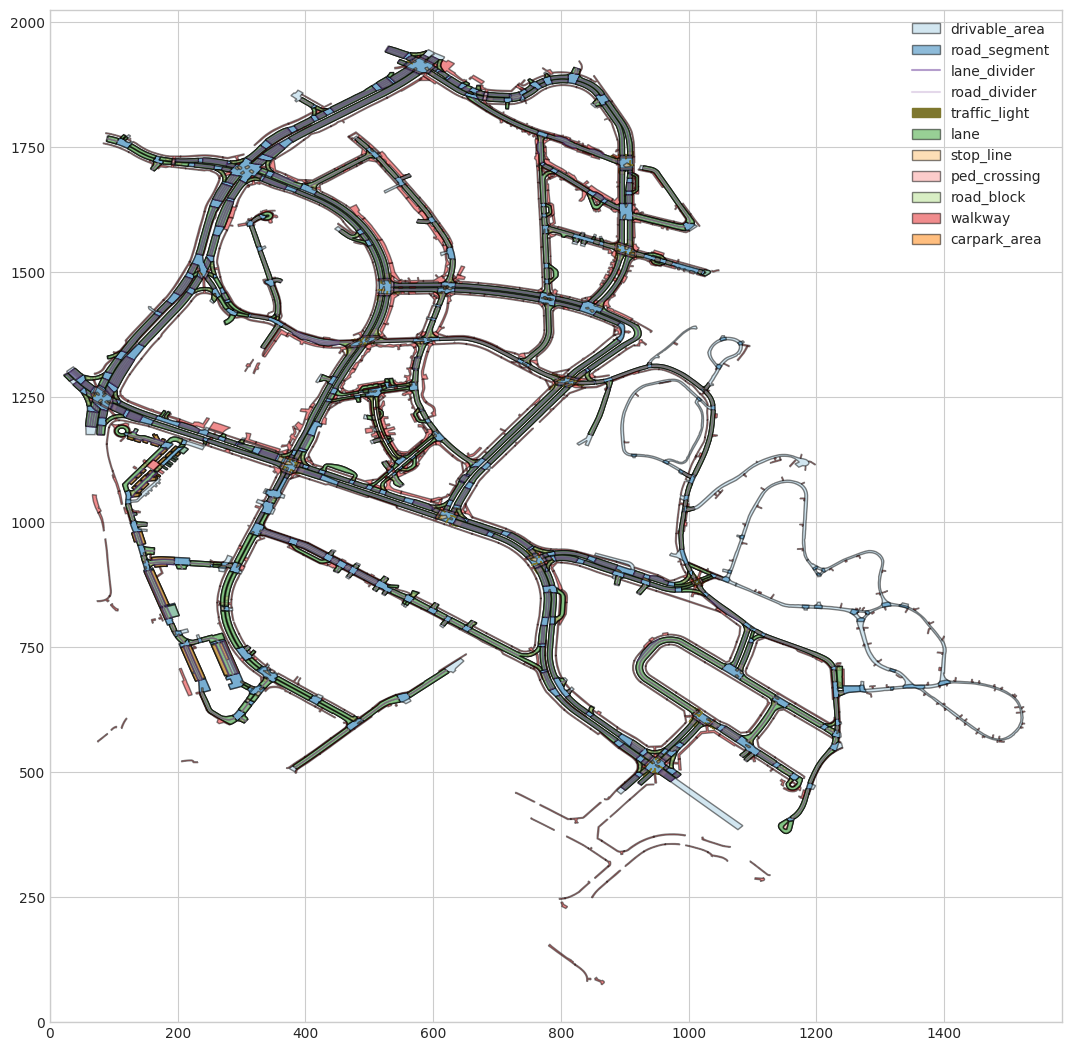

In [5]:
fig, ax = nusc_map.render_layers(nusc_map.non_geometric_layers, figsize=1)

### Rendering the lidar basemap

**New**: We can render the HD lidar basemap used for localization. The basemap is a bitmap image that can be underlaid for most functions (`render_centerlines`, `render_egoposes_on_fancy_map`, `render_layers`, `render_map_patch`, `render_next_roads`, `render_record`). The same `BitMap` class can also be used to render the semantic prior (drivable surface + sidewalk) from the original nuScenes release. Note that in this visualization we only show the `lane`

bitmap = BitMap(nusc_map.dataroot, nusc_map.map_name, 'basemap')
fig, ax = nusc_map.render_layers(['lane'], figsize=1, bitmap=bitmap)

 annotations for better visibility.

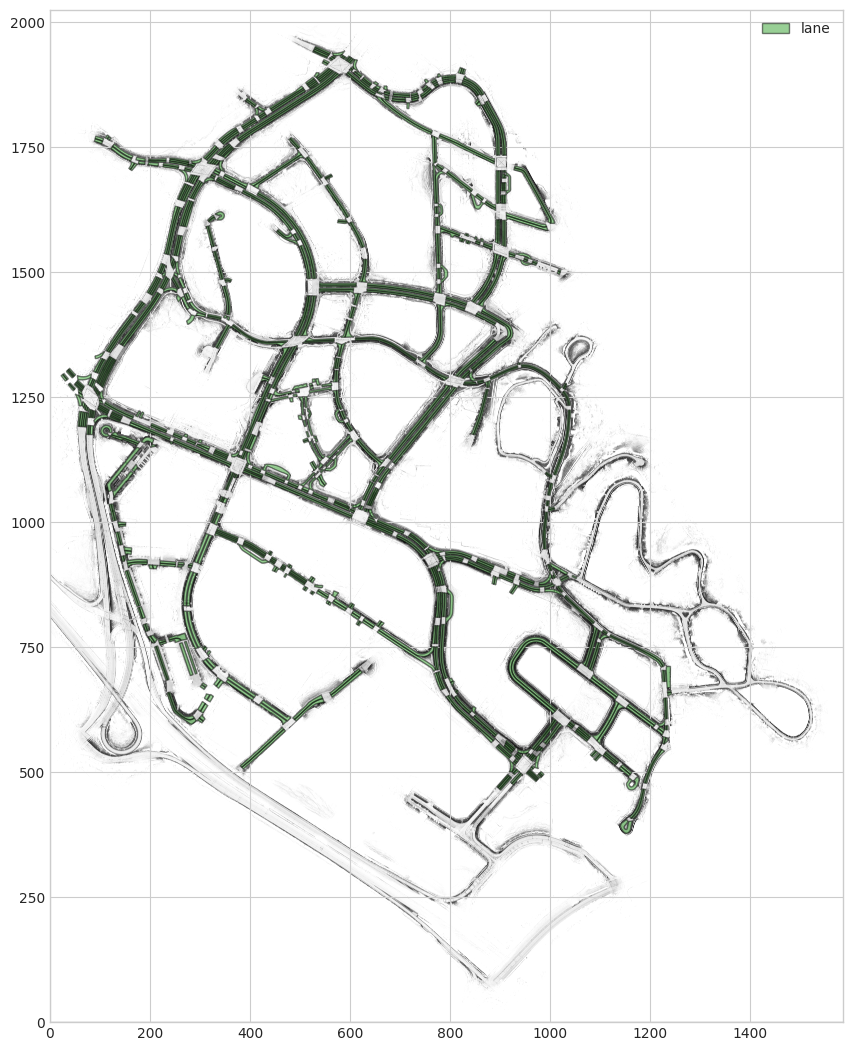

In [6]:
bitmap = BitMap(nusc_map.dataroot, nusc_map.map_name, 'basemap')
fig, ax = nusc_map.render_layers(['lane'], figsize=1, bitmap=bitmap)

### Rendering binary map mask layers

The `NuScenesMap` class makes it possible to convert multiple map layers into binary mask and render on a Matplotlib figure. First let's call `get_map_mask` to look at the raw data of two layers:

In [7]:
patch_box = (300, 1700, 100, 100)
patch_angle = 0  # Default orientation where North is up
layer_names = ['drivable_area', 'walkway']
canvas_size = (1000, 1000)
map_mask = nusc_map.get_map_mask(patch_box, patch_angle, layer_names, canvas_size)
map_mask[0]

/usr/local/lib/python3.8/dist-packages/nuscenes/map_expansion/map_api.py:1823: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  exteriors = [int_coords(poly.exterior.coords) for poly in polygons]
/usr/local/lib/python3.8/dist-packages/nuscenes/map_expansion/map_api.py:1824: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  interiors = [int_coords(pi.coords) for poly in polygons for pi in poly.interiors]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], dtype=uint8)

Now we directly visualize the map mask retrieved above using render_map_mask:

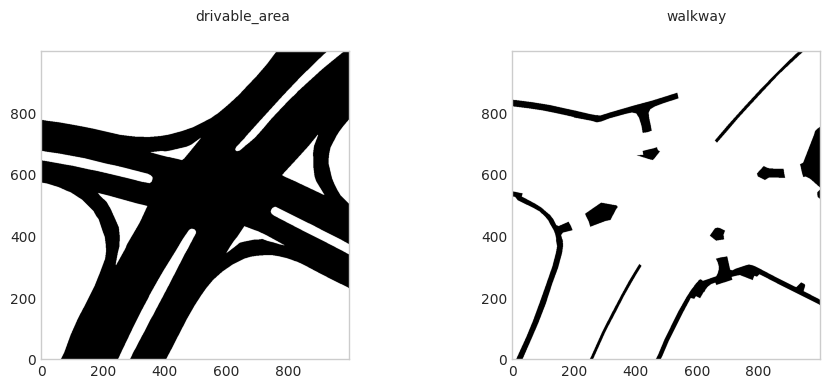

In [8]:
figsize = (12, 4)
fig, ax = nusc_map.render_map_mask(patch_box, patch_angle, layer_names, canvas_size, figsize=figsize, n_row=1)

We can also render the same map rotated by 45 degrees clockwise:

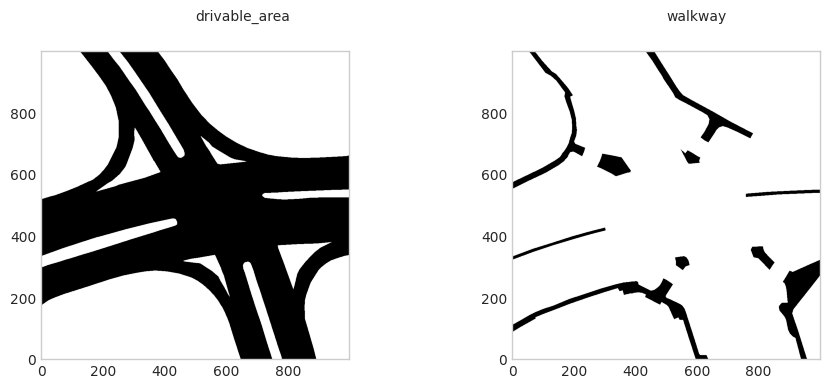

In [9]:
fig, ax = nusc_map.render_map_mask(patch_box, 45, layer_names, canvas_size, figsize=figsize, n_row=1)

### Rendering map layers on top of camera images

Let us take a nuScenes camera image and overlay the relevant map layers. Note that the projections are not perfect if the ground is uneven as the localization is 2d.

(<Figure size 900x1600 with 1 Axes>, <Axes: >)

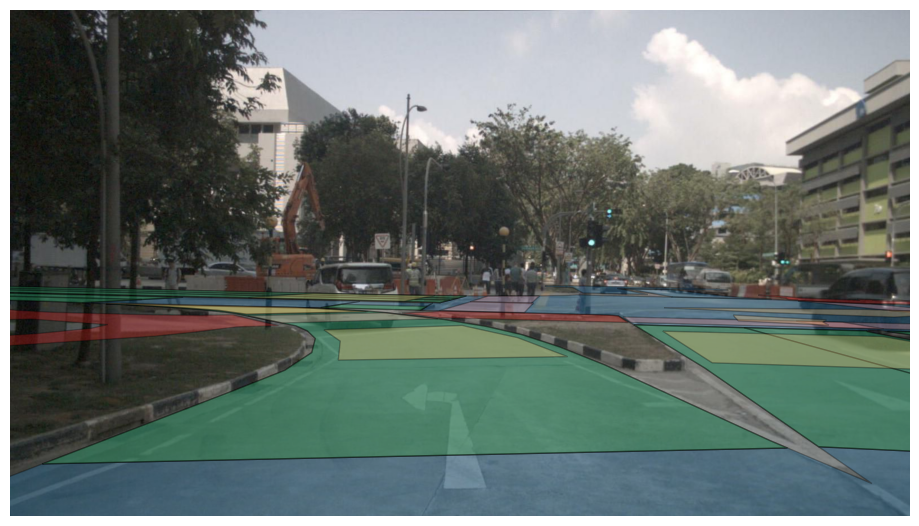

In [14]:
# Init nuScenes. Requires the dataset to be stored on disk.
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version='v1.0-mini', dataroot=nusc_map.dataroot, verbose=False)

# Pick a sample and render the front camera image.
sample_token = nusc.sample[9]['token']
layer_names = ['road_segment', 'lane', 'ped_crossing', 'walkway', 'stop_line', 'carpark_area']
camera_channel = 'CAM_FRONT'
nusc_map.render_map_in_image(nusc, sample_token, layer_names=layer_names, camera_channel=camera_channel)

### Rendering ego poses on the map

We can also plot the ego poses onto the map. This requires us to load up the `NuScenes` class, which can take some time.

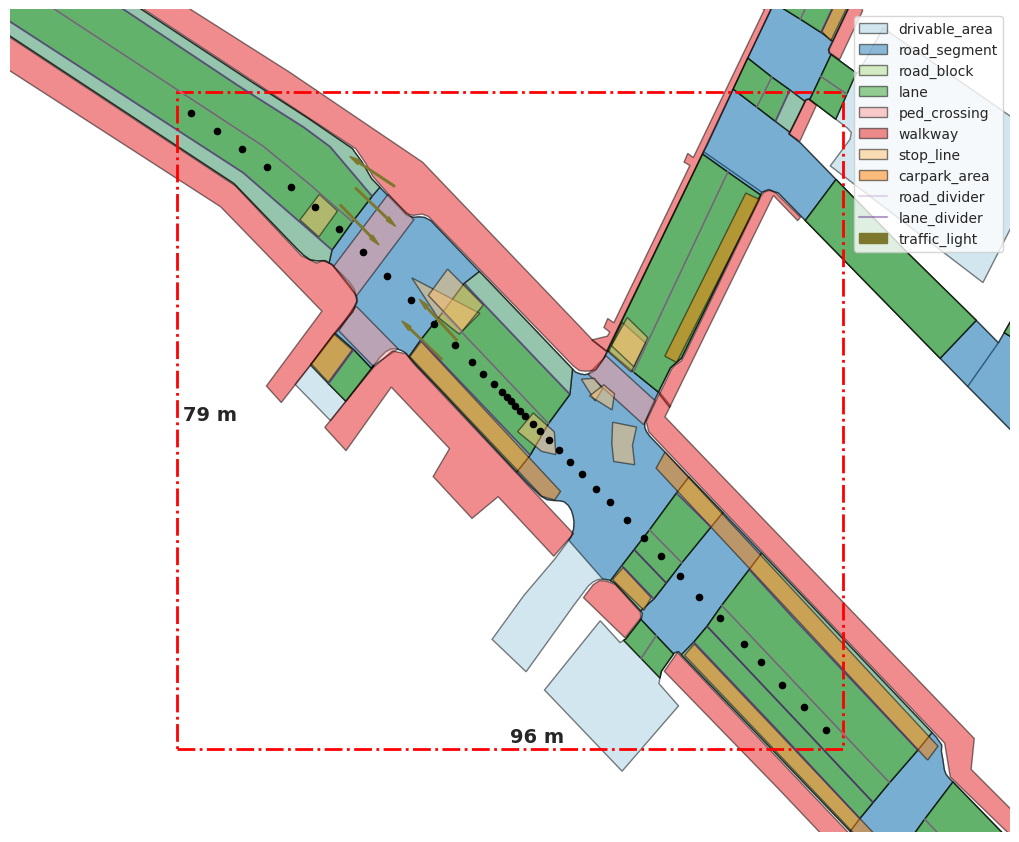

In [17]:
# Init NuScenes. Requires the dataset to be stored on disk.
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version='v1.0-mini', dataroot=nusc_map.dataroot, verbose=False)

# Render ego poses.
nusc_map_bos = NuScenesMap(dataroot=nusc_map.dataroot, map_name='boston-seaport')
ego_poses = nusc_map_bos.render_egoposes_on_fancy_map(nusc, scene_tokens=[nusc.scene[1]['token']], verbose=False)

## Navigation

We also provide functions for navigation around the road network. For this purpose, the road layers `lane`, `road_block` and `road_segment` are especially useful (see definitions below). The `get_next_roads(x, y)` function looks at the road layer at a particular point. It then retrieves the next road object in the direction of the `lane` or `road_block`. As `road_segments` do not have a direction (e.g. intersections), we return all possible next roads.

In [18]:
x = 873
y = 1286
print('Road objects on selected point:', nusc_map.layers_on_point(x, y), '\n')
print('Next road objects:', nusc_map.get_next_roads(x, y))

Road objects on selected point: {'drivable_area': 'c3e28556-b711-4581-9970-b66166fb907d', 'road_segment': '57416e99-8919-4a28-985b-033a16938243', 'road_block': '', 'lane': '', 'ped_crossing': '', 'walkway': '', 'stop_line': '', 'carpark_area': ''} 

Next road objects: {'road_segment': ['3493d68c-5217-4d21-ae1b-3cbf4467dd77', '4b0e50c0-c549-49a2-9077-57a8cba8ab55', '5428b143-6343-4045-ac81-466df3dcc510'], 'road_block': ['5c286ee8-7b4d-4cd8-84bb-7486e77ba827', '8b33213a-692e-4c5f-a69a-efa6836f5316', '9aa7a714-30ba-4892-a276-c033928a8ae2', '9c506cc4-7d14-475d-8063-22a5b9bc257f', 'b7cc94f4-3882-4df2-a9ae-9349925809a1', 'e0c4f027-ea81-40f2-bafc-3fb8e8ab78c3'], 'lane': ['525b6716-a12e-4dd0-8541-91ef672ce39b', '5fdd162d-477d-4bc4-ada3-535d79a9f4b1', '8658217b-87d6-4f8b-96be-35d53100247d', 'b7378bda-dedf-4f97-9d87-b0dd602fdab5', 'bce7caf7-5e33-48d6-b0aa-8b5b641c8ce5', 'f747ce8a-2396-4da3-a8e6-45201ed470d6']}


We can also visualize the next roads using the render_next_roads(x, y) function. We see that there are 3 adjacent roads to the intersection specified by (x, y).

(<Figure size 1012.5x792.8 with 1 Axes>, <Axes: >)

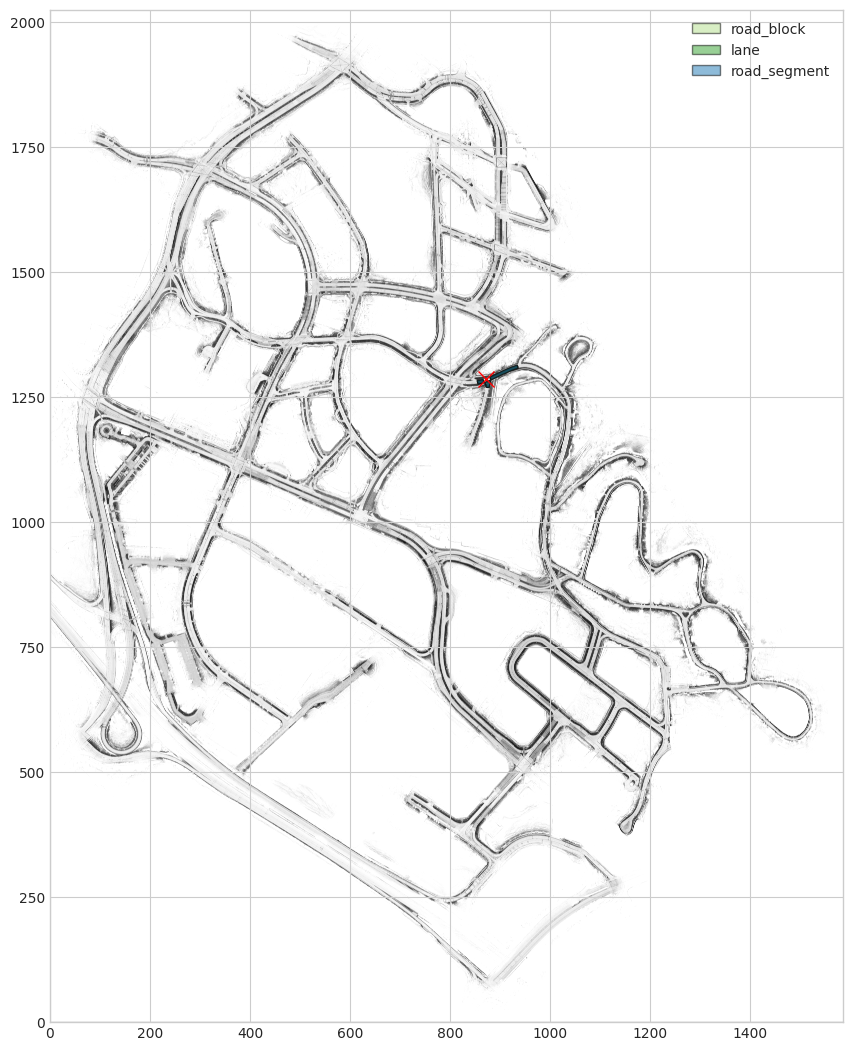

In [19]:
nusc_map.render_next_roads(x, y, figsize=1, bitmap=bitmap)

### Working with Lanes

For the prediction challenge we added connectivity information to the map expansion (v1.2) to efficiently query which lane is connected to which other lanes. Below we render the lane and lane_connector objects. The lanes and lane_connectors are defined by parametric curves. The `resolution_meters` parameter specifies the discretization resolution of the curve. If we set it to a high value (e.g. 100), the curves will appear as straight lines. We recommend setting this value to 1m or less.

(<Figure size 1012.5x792.8 with 1 Axes>, <Axes: >)

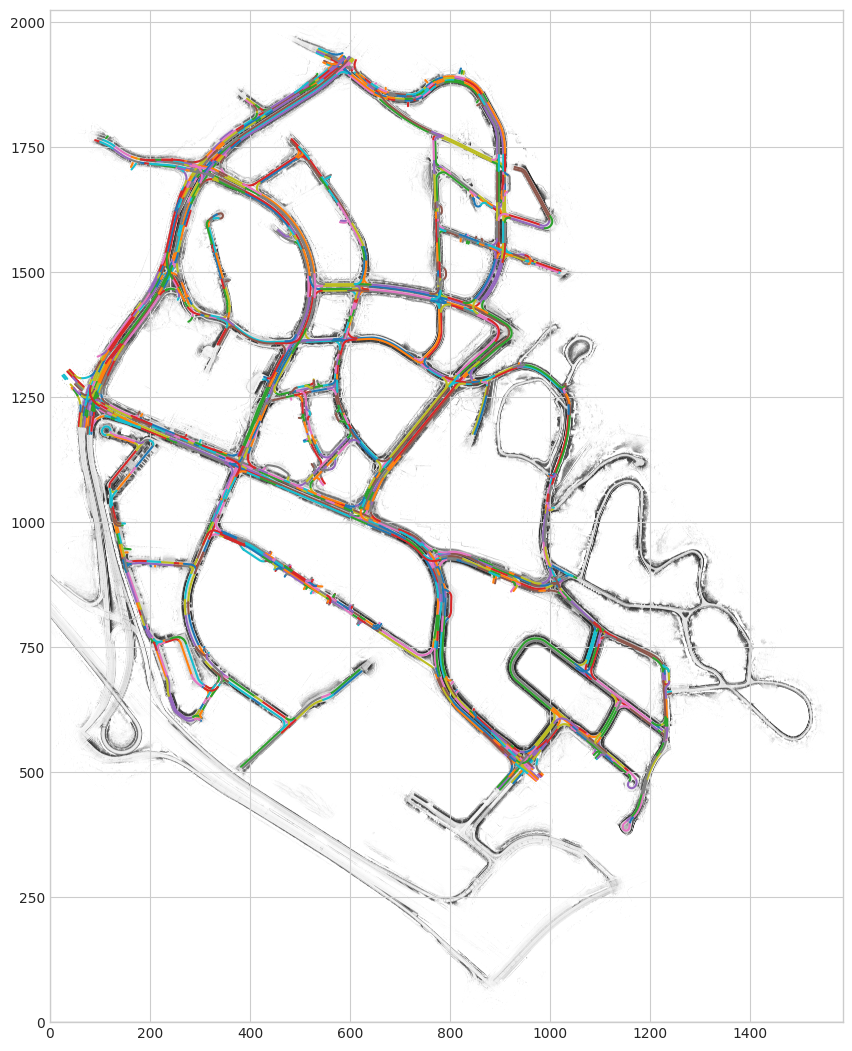

In [20]:
nusc_map.render_centerlines(resolution_meters=0.5, figsize=1, bitmap=bitmap)

To get the closest lane to a location, use the `get_closest_lane` method. To see the internal data representation of the lane, use the `get_lane_record` method. You can also explore the connectivity of the lanes, with the `get_outgoing_lanes` and `get_incoming_lane` methods.

In [21]:
x, y, yaw = 395, 1095, 0
closest_lane = nusc_map.get_closest_lane(x, y, radius=2)
closest_lane

'5933500a-f0f2-4d69-9bbc-83b875e4a73e'

In [22]:
lane_record = nusc_map.get_arcline_path(closest_lane)
lane_record

[{'start_pose': [421.2419602954602, 1087.9127960414617, 2.739593514975998],
  'end_pose': [391.7142849867393, 1100.464077182952, 2.7365754617298705],
  'shape': 'LSR',
  'radius': 999.999,
  'segment_length': [0.23651121617864976,
   28.593481378991886,
   3.254561444252876]}]

In [23]:
nusc_map.get_incoming_lane_ids(closest_lane)

['f24a067b-d650-47d0-8664-039d648d7c0d']

In [24]:
nusc_map.get_outgoing_lane_ids(closest_lane)

['0282d0e3-b6bf-4bcd-be24-35c9ce4c6591',
 '28d15254-0ef9-48c3-9e06-dc5a25b31127']

To help manipulate the lanes, we've added an arcline_path_utils module. For example, something you might want to do is discretize a lane into a sequence of poses.

In [25]:
poses = arcline_path_utils.discretize_lane(lane_record, resolution_meters=1)
poses

[(421.2419602954602, 1087.9127960414617, 2.739593514975998),
 (420.34712994585345, 1088.2930152148274, 2.739830026428688),
 (419.45228865726136, 1088.6732086473173, 2.739830026428688),
 (418.5574473686693, 1089.0534020798073, 2.739830026428688),
 (417.66260608007724, 1089.433595512297, 2.739830026428688),
 (416.76776479148515, 1089.813788944787, 2.739830026428688),
 (415.87292350289306, 1090.1939823772768, 2.739830026428688),
 (414.97808221430097, 1090.5741758097668, 2.739830026428688),
 (414.0832409257089, 1090.9543692422567, 2.739830026428688),
 (413.1883996371168, 1091.3345626747464, 2.739830026428688),
 (412.29355834852475, 1091.7147561072363, 2.739830026428688),
 (411.39871705993266, 1092.0949495397263, 2.739830026428688),
 (410.5038757713406, 1092.4751429722162, 2.739830026428688),
 (409.6090344827485, 1092.8553364047061, 2.739830026428688),
 (408.7141931941564, 1093.2355298371958, 2.739830026428688),
 (407.81935190556436, 1093.6157232696858, 2.739830026428688),
 (406.92451061697

Given a query pose, you can also find the closest pose on a lane.

In [26]:
closest_pose_on_lane, distance_along_lane = arcline_path_utils.project_pose_to_lane((x, y, yaw), lane_record)

In [27]:
print(x, y, yaw)
closest_pose_on_lane

395 1095 0


(396.25524909914367, 1098.5289922434013, 2.739830026428688)

In [28]:
# Meters
distance_along_lane

27.5

To find the entire length of the lane, you can use the length_of_lane function.

In [29]:
arcline_path_utils.length_of_lane(lane_record)

32.08455403942341

You can also compute the curvature of a lane at a given length along the lane.

In [30]:
# 0 means it is a straight lane
arcline_path_utils.get_curvature_at_distance_along_lane(distance_along_lane, lane_record)

0

## Data Exploration

Let's render a particular patch on the map:

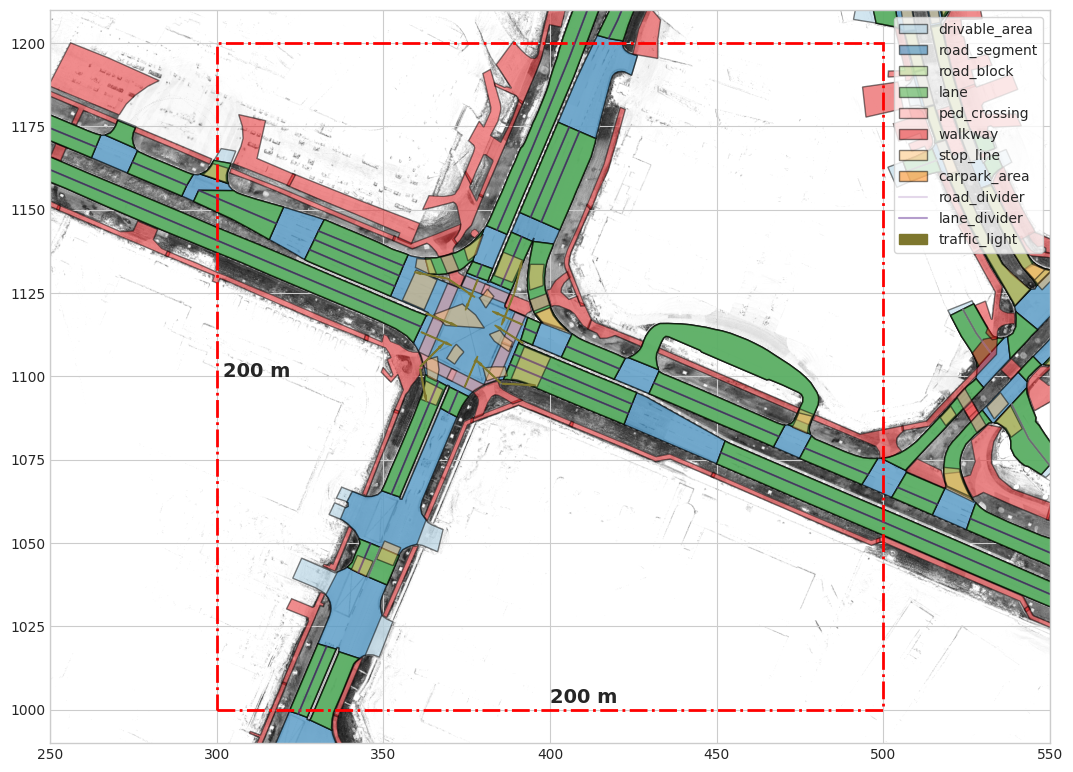

In [31]:
my_patch = (300, 1000, 500, 1200)
fig, ax = nusc_map.render_map_patch(my_patch, nusc_map.non_geometric_layers, figsize=(10, 10), bitmap=bitmap)

A lot of layers can be seen in this patch. Lets retrieve all map records that are in this patch.

- The option `within` will return all non geometric records that **are within** the map patch
- The option `intersect` will return all non geometric records that **intersect** the map patch

In [32]:
records_within_patch = nusc_map.get_records_in_patch(my_patch, nusc_map.non_geometric_layers, mode='within')
records_intersect_patch = nusc_map.get_records_in_patch(my_patch, nusc_map.non_geometric_layers, mode='intersect')

Since there are a lot of records, we focus only on the layer `road_segment`:

In [33]:
layer = 'road_segment'
print('Found %d records of %s (within).' % (len(records_within_patch[layer]), layer))
print('Found %d records of %s (intersect).' % (len(records_intersect_patch[layer]), layer))

Found 25 records of road_segment (within).
Found 36 records of road_segment (intersect).


We see that using the option `intersect` typically returns more records than `within`.

Looking at the above plot. Point `(390, 1100)` seems to be on a stop line. Lets verify that.

In [35]:
my_point = (390, 1100)
layers = nusc_map.layers_on_point(my_point[0], my_point[1])
assert len(layers['stop_line']) > 0, 'Error: No stop line found!'

Indeed, we see a stop_line record.

To directly check for stop_line records, we run:

In [36]:
nusc_map.record_on_point(my_point[0], my_point[1], 'stop_line')

'942dc2b1-345c-4fe7-83d0-9eeed8202709'

Let's look at the bounds/extremities of that record

In [37]:
nusc_map.get_bounds('stop_line', 'ac0a935f-99af-4dd4-95e3-71c92a5e58b1')

(751.928131680929, 920.9848298895206, 762.8608345788314, 929.439260149884)

## Layers

Let us look more closely at the different map layers:

In [38]:
nusc_map.layer_names

['polygon',
 'line',
 'node',
 'drivable_area',
 'road_segment',
 'road_block',
 'lane',
 'ped_crossing',
 'walkway',
 'stop_line',
 'carpark_area',
 'lane_connector',
 'road_divider',
 'lane_divider',
 'traffic_light']

Our map database consists of multiple layers. Where each **layer** is made up of **records**. Each record will have a token identifier.

We see how our map layers are divided into two types of layers. One set of layer belong to the `geometric_layers` group, another set of layers belongs to the `non_geometric_layers` group.

1. `geometric_layers` define geometric entities in the map:
  - Nodes (2d points) are the basis for all geometric layers.
  - Lines consist of two or more nodes. Formally, one Line record can consist of more than one line segment.
  - Polygons consist of three or more nodes. A polygon can have holes, thus distorting its formal definition. Holes are defined as a sequence of nodes that forms the perimeter of the polygonal hole.

2. `non_geometric_layers` represent physical entities in the map. They can have more than one geometric representation (such as `drivable_areas`), but must be strictly of one type (e.g. `road_segment`, `lane_divider`).

### 1. Geometric layers